<a href="https://colab.research.google.com/github/saravkulkarni/Innovation-Lab/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 – Classification

## Learning Objectives

By the end of this chapter, you should be able to:

- Explain what classification is in your own words;
- Distinguish between classification and regression;
- Describe several common classification algorithms and their use cases;
- Train a simple classification model in Python;
- Interpret a confusion matrix and a feature importance plot;
- Recognise common pitfalls in classification.

## 4.1 What is Classification?

**Classification** is a supervised learning task:  
given input features, predict a **discrete class**.

Examples:

- Given an email, decide whether it is "spam" or "not spam";
- Given flower measurements, decide which species of iris it is;
- Given a medical image, decide whether a tumour is "benign" or "malignant".

### Classification vs Regression

| | Classification | Regression |
|---|---|---|
| Output | Discrete class | Continuous number |
| Example | Spam / Not spam | House price, temperature |
| Typical algorithms | Logistic Regression, Random Forest | Linear Regression |

This chapter focuses on classification. Regression is covered in Chapter 5.

## 4.2 The Intuitive Workflow of Classification

A typical classification workflow looks like this:

1. **Collect data**: obtain labelled samples;
2. **Prepare data**: clean it, split into training and test sets;
3. **Choose a model**: e.g., Random Forest;
4. **Train the model**: let it learn from the training data;
5. **Predict**: assign classes to new samples;
6. **Evaluate**: check how accurate the predictions are.

This chapter will walk you through this workflow.

## 4.3 Common Classification Algorithms (Conceptual)

You do not need to derive these algorithms, but you should know roughly what they do and when to use them.

| Algorithm | Intuition | Pros | Cons |
|---|---|---|---|
| **Logistic Regression** | Draws a line (or hyperplane) to separate classes | Simple, interpretable | Only linear boundaries |
| **k-Nearest Neighbours (k-NN)** | Looks at the k closest neighbours and takes a vote | Very intuitive, no training | Slow prediction, sensitive to scale |
| **Decision Tree** | A series of if/else questions | Interpretable, handles non-linearity | Prone to overfitting |
| **Random Forest** | Many decision trees vote together | Stable, accurate, widely used | Harder to interpret than a single tree |
| **Support Vector Machine (SVM)** | Finds the widest possible separating boundary | Good for small data, high dimensions | Many parameters, slow on large data |
| **Naive Bayes** | Uses probabilities to make decisions | Fast, good for text | Assumes features are independent |

In this chapter we will use **Random Forest** for the case study, because it is stable, effective, and less prone to overfitting.

## 4.4 Case Study: Iris Flower Classification

We use the classic **Iris dataset**.  
It contains measurements of 150 iris flowers:

- Features: sepal length, sepal width, petal length, petal width;
- Labels: three species (setosa, versicolor, virginica).

Goal: predict the species from the measurements.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plotting style
sns.set_style("whitegrid")

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Feature matrix X and labels y
X = iris.data
y = iris.target

# Convert to a DataFrame for easier inspection
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

# Show the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Check class distribution
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [ ]:
# Split into training and test sets
# 80% training, 20% testing; stratify keeps class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (120, 4)
Test set size: (30, 4)


In [ ]:
# Create a Random Forest classifier
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.90

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



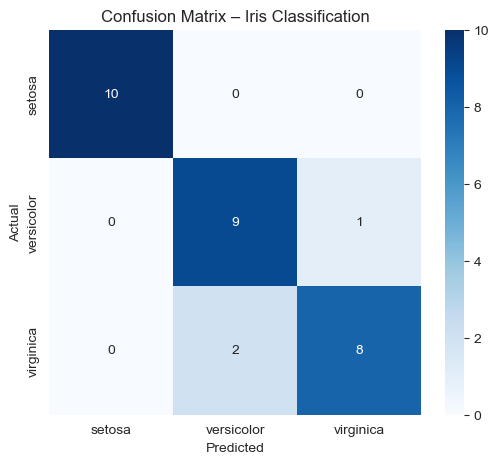

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Iris Classification")
plt.show()

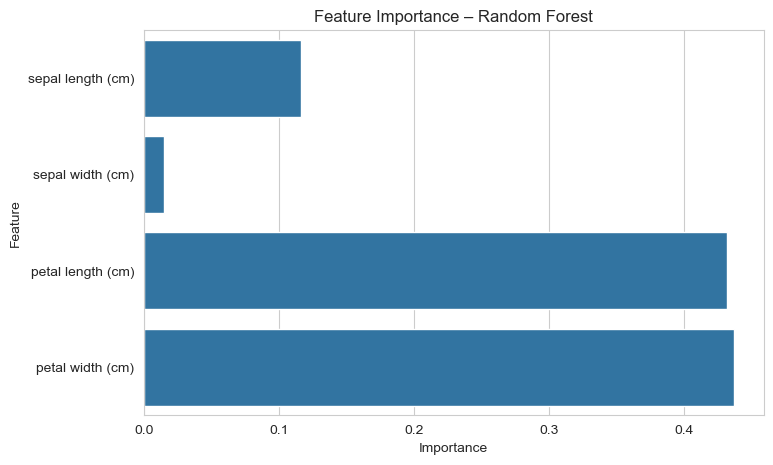

In [ ]:
# Feature importances
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=iris.feature_names)
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 4.5 Interpreting the Results

### Accuracy

Accuracy is the proportion of correct predictions on the test set.  
In this example, accuracy is usually high (around 0.9 or above) because the Iris dataset is relatively simple.

### Confusion Matrix

The rows are **actual classes**, the columns are **predicted classes**.

- Numbers on the diagonal: correct predictions;
- Off-diagonal numbers: incorrect predictions.

For example, if the `setosa` row has all its counts on the diagonal, it means all setosa flowers were correctly classified.

### Feature Importance

Random Forest tells us which features are most important for classification.  
In the Iris dataset, **petal length** and **petal width** are usually the most important features.

## 4.6 Common Pitfalls

1. **Looking only at accuracy**  
   If classes are imbalanced (e.g., 99% not spam), predicting "not spam" for everything still gives 99% accuracy.  
   You then need Precision, Recall, and F1 (see Chapter 6).

2. **Overfitting**  
   The model performs well on training data but poorly on test data.  
   Solutions: train/test split, cross-validation (see Chapter 7).

3. **Data leakage**  
   Using information from the test set during training.  
   Solution: keep training and test sets strictly separate.

4. **Treating classification as regression**  
   Classification outputs classes; regression outputs numbers.  
   Choosing the wrong model leads to meaningless results.

## 4.7 Summary

- Classification is a supervised learning task that predicts discrete classes;
- Common algorithms include Logistic Regression, k-NN, Decision Tree, and Random Forest;
- `scikit-learn` makes it easy to train and evaluate classification models;
- The confusion matrix and feature importance plot are essential tools for understanding classification results;
- Next step: Chapter 6 explains how to evaluate models in more depth.

### Further Resources

- scikit-learn classifiers: https://scikit-learn.org/stable/supervised_learning.html
- Iris dataset description: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html